N7023-SEMCD-14_UdayKiranMudu

In [ ]:
# ==============================================================================
# 1. ENVIRONMENT INITIALIZATION & LIBRARIES
# ==============================================================================
!pip install pyspark -q

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder.master("local[*]").appName(
    "Customer_Segmentation_Classification"
).getOrCreate()

In [ ]:
# ==============================================================================
# 2. DATA LOADING & INSPECTION
# ==============================================================================
# Read dataset into Spark DataFrame
dataset = spark.read.csv(
    'customer_segmentation_dataset.csv', inferSchema=True, header=True
)

print('Dataset Schema:')
dataset.printSchema()

print('Class Distribution in Target Column (customer_segment):')
dataset.select('customer_segment').distinct().show()
print(f'Total Record Count: {dataset.count()}')

Dataset Schema:
root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)

Class Distribution in Target Column (customer_segment):
+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

Total Record Count: 1025237


In [ ]:
# ==============================================================================
# 3. FEATURE ASSEMBLY & LABEL INDEXING
# ==============================================================================
# Assemble numerical features into a single feature vector
feature_cols = [
    'age',
    'annual_income',
    'spending_score',
    'years_as_customer',
    'number_of_purchases',
]
vector_assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_temp = vector_assembler.transform(dataset)

# Convert categorical text labels ("Low Value", "Medium Value", "High Value") to numeric index values (0.0, 1.0, 2.0)
l_indexer = StringIndexer(inputCol='customer_segment', outputCol='labelIndex')
df = l_indexer.fit(df_temp).transform(df_temp)

# Select processed columns
df_model = df.select('features', 'customer_segment', 'labelIndex')
df_model.show(3, truncate=False)

# Map string labels to indexed values for verification
df_model.select('customer_segment', 'labelIndex').distinct().show()

+-----------------------------+----------------+----------+
|features                     |customer_segment|labelIndex|
+-----------------------------+----------------+----------+
|[22.0,113441.0,19.0,2.0,44.0]|Low Value       |0.0       |
|[47.0,85415.0,74.0,7.0,11.0] |Medium Value    |1.0       |
|[60.0,78075.0,18.0,19.0,37.0]|Low Value       |0.0       |
+-----------------------------+----------------+----------+
only showing top 3 rows
+----------------+----------+
|customer_segment|labelIndex|
+----------------+----------+
|      High Value|       2.0|
|    Medium Value|       1.0|
|       Low Value|       0.0|
+----------------+----------+



In [ ]:
# ==============================================================================
# 4. TRAIN / TEST SPLIT
# ==============================================================================
# Split data into 70% Training and 30% Testing
(trainingData, testData) = df_model.randomSplit([0.7, 0.3], seed=1234)

In [ ]:
# ==============================================================================
# 5. MULTICLASS CLASSIFICATION MODEL 1: DECISION TREE
# ==============================================================================
# Train Decision Tree Classifier
dt = DecisionTreeClassifier(
    labelCol='labelIndex',
    featuresCol='features',
    impurity='entropy',
    maxDepth=4,
    seed=1234,
)
dt_model = dt.fit(trainingData)
dt_predictions = dt_model.transform(testData)

# Evaluate Decision Tree Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol='labelIndex', predictionCol='prediction', metricName='accuracy'
)
dt_accuracy = evaluator.evaluate(dt_predictions)
print(f'Decision Tree Test Accuracy = {dt_accuracy:.4f}')

# Output Decision Tree Decision Rules
print('\nDecision Tree Structure:')
print(dt_model.toDebugString)

Decision Tree Test Accuracy = 0.9797

Decision Tree Structure:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_412d561926af, depth=2, numNodes=5, numClasses=3, numFeatures=5
  If (feature 2 <= 49.5)
   Predict: 0.0
  Else (feature 2 > 49.5)
   If (feature 2 <= 74.5)
    Predict: 1.0
   Else (feature 2 > 74.5)
    Predict: 2.0



In [ ]:
# ==============================================================================
# 6. MULTICLASS CLASSIFICATION MODEL 2: ONE-VS-REST LOGISTIC REGRESSION
# ==============================================================================
# Train Logistic Regression using OneVsRest strategy for multiclass classification
lr = LogisticRegression(
    maxIter=100, featuresCol='features', labelCol='labelIndex'
)
ovr = OneVsRest(
    classifier=lr, labelCol='labelIndex', featuresCol='features'
)

ovrModel = ovr.fit(trainingData)
ovr_predictions = ovrModel.transform(testData)

# Evaluate OneVsRest Logistic Regression Accuracy
ovr_accuracy = evaluator.evaluate(ovr_predictions)
print(f'OneVsRest Logistic Regression Test Accuracy = {ovr_accuracy:.4f}')

OneVsRest Logistic Regression Test Accuracy = 1.0000


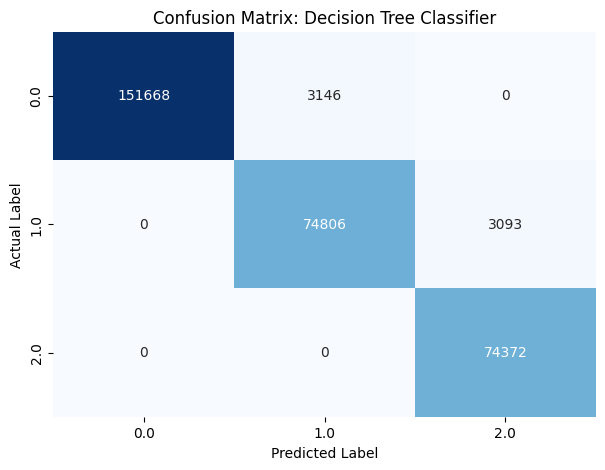

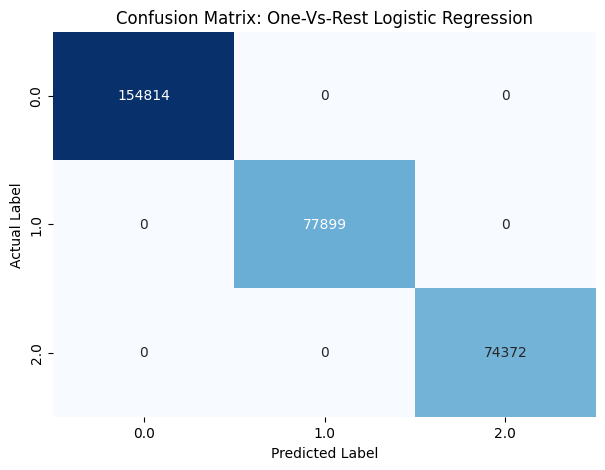

In [ ]:
# ==============================================================================
# 7. CONFUSION MATRIX GENERATION & VISUALIZATION
# ==============================================================================
# Function to plot Seaborn Heatmap Confusion Matrix
def plot_confusion_matrix(predictions_df, model_title):
  # Convert predictions to Pandas DataFrame
  pd_preds = predictions_df.select('prediction', 'labelIndex').toPandas()

  # Compute cross-tabulation confusion matrix
  cm = pd.crosstab(
      pd_preds['labelIndex'],
      pd_preds['prediction'],
      rownames=['Actual'],
      colnames=['Predicted'],
  )

  # Plot Heatmap
  plt.figure(figsize=(7, 5))
  sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
  plt.title(f'Confusion Matrix: {model_title}')
  plt.xlabel('Predicted Label')
  plt.ylabel('Actual Label')
  plt.show()


# Display Confusion Matrices for both models
plot_confusion_matrix(dt_predictions, 'Decision Tree Classifier')
plot_confusion_matrix(ovr_predictions, 'One-Vs-Rest Logistic Regression')